In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# Plot settings
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

In [2]:
markets = pd.read_csv(r'/home/diegom/Proyectos-DS/Polymarket_Prediction_Markets/polymarket_markets.csv', low_memory=False )

In [3]:
events = pd.read_csv(r'/home/diegom/Proyectos-DS/Polymarket_Prediction_Markets/polymarket_events.csv', low_memory=False )

In [4]:
markets.shape


(100795, 138)

In [5]:
events.shape

(43840, 80)

In [6]:
markets.columns.tolist()

['acceptingOrders',
 'acceptingOrdersTimestamp',
 'active',
 'approved',
 'archived',
 'automaticallyActive',
 'automaticallyResolved',
 'bestAsk',
 'bestBid',
 'category',
 'categoryMailchimpTag',
 'clearBookOnStart',
 'clobRewards',
 'clobTokenIds',
 'closed',
 'closedTime',
 'commentsEnabled',
 'competitive',
 'conditionId',
 'createdAt',
 'createdBy',
 'creator',
 'customLiveness',
 'cyom',
 'denominationToken',
 'deploying',
 'deployingTimestamp',
 'description',
 'disqusThread',
 'enableOrderBook',
 'endDate',
 'endDateIso',
 'eventStartTime',
 'event_id',
 'event_slug',
 'event_title',
 'featured',
 'fee',
 'feesEnabled',
 'formatType',
 'fpmmLive',
 'funded',
 'gameId',
 'gameStartTime',
 'groupItemRange',
 'groupItemThreshold',
 'groupItemTitle',
 'hasReviewedDates',
 'holdingRewardsEnabled',
 'icon',
 'id',
 'image',
 'lastTradePrice',
 'line',
 'liquidity',
 'liquidityAmm',
 'liquidityClob',
 'liquidityNum',
 'lowerBound',
 'mailchimpTag',
 'makerBaseFee',
 'manualActivation

In [7]:
(markets.isnull().sum() / len(markets) * 100).sort_values(ascending=False).head(20)

creator                     100.000000
denominationToken           100.000000
sponsorImage                100.000000
createdBy                    99.999008
teamBID                      99.996032
teamAID                      99.996032
groupItemRange               99.995039
categoryMailchimpTag         99.948410
disqusThread                 99.945434
twitterCardImage             99.938489
formatType                   99.934521
subcategory                  99.934521
upperBound                   99.929560
lowerBound                   99.929560
seriesColor                  99.898805
twitterCardLastValidated     98.597153
notificationsEnabled         98.028672
gameId                       97.976090
marketGroup                  97.936406
mailchimpTag                 97.636788
dtype: float64

In [8]:
(events.isnull().sum() / len(events) * 100).sort_values(ascending=False).head(20)

carouselMap        99.997719
cantEstimate       99.997719
estimatedValue     99.997719
estimateValue      99.997719
tweetCount         99.963504
eventCreators      99.947536
disqusThread       99.940693
electionType       99.933850
countryName        99.931569
createdBy          99.879106
subcategory        99.847172
featuredOrder      99.831204
negRiskFeeBips     99.822080
elapsed            99.801551
featuredImage      99.468522
updatedBy          98.895985
parentEventId      97.933394
gmpChartMode       96.482664
commentsEnabled    95.567974
category           93.553832
dtype: float64

In [9]:
financial_cols = ['volume', 'volume24hr', 'volume1wk', 'liquidity', 
                  'bestBid', 'bestAsk', 'spread', 'lastTradePrice',
                  'competitive', 'active', 'closed']

markets[financial_cols].describe()

,volume,volume24hr,volume1wk,liquidity,bestBid,bestAsk,spread,lastTradePrice,competitive
count,9.433400e+04,2.656200e+04,7.269100e+04,5.783300e+04,71369.000000,100795.000000,100795.000000,90167.000000,57833.000000
mean,8.510464e+04,5.652330e+03,5.510834e+04,5.602778e+03,0.420530,0.532078,0.234166,0.616218,0.217153
std,9.204678e+05,7.818571e+04,3.472236e+05,5.216273e+04,0.421195,0.445057,0.394192,0.446301,0.369113
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.001000,0.001000,0.000000,0.000000
25%,2.365461e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.003000,0.001000,0.010000,0.000000
50%,3.832240e+03,0.000000e+00,2.221000e+03,0.000000e+00,0.290000,0.550000,0.010000,0.990000,0.000000
75%,2.461042e+04,3.119017e+01,2.021245e+04,2.000651e+02,0.990000,1.000000,0.180000,1.000000,0.364308
max,9.468609e+07,7.361079e+06,2.881534e+07,7.039340e+06,0.999000,1.919000,1.000000,1.000000,1.000000


In [10]:
markets[financial_cols].isnull().sum()

volume             6461
volume24hr        74233
volume1wk         28104
liquidity         42962
bestBid           29426
bestAsk               0
spread                0
lastTradePrice    10628
competitive       42962
active                0
closed                0
dtype: int64

In [11]:
markets[['active', 'closed', 'archived']].value_counts(dropna=False)

active  closed  archived
True    True    False       75265
        False   False       16473
False   False   False        7846
        True    False        1062
        False   True          143
        True    True            4
True    False   True            2
Name: count, dtype: int64

In [12]:
markets[markets['bestAsk'] > 1][['question', 'bestAsk', 'bestBid', 'spread', 'volume']].head(10)

,question,bestAsk,bestBid,spread,volume
95938,Will Trump and Zelenskyy shake hands for betwe...,1.919,0.999,0.92,7708.170369


In [13]:
events.columns.tolist()

['active',
 'archived',
 'automaticallyActive',
 'automaticallyResolved',
 'awayTeamName',
 'cantEstimate',
 'carouselMap',
 'category',
 'closed',
 'closedTime',
 'commentCount',
 'commentsEnabled',
 'competitive',
 'countryName',
 'createdAt',
 'createdBy',
 'creationDate',
 'cyom',
 'deploying',
 'deployingTimestamp',
 'description',
 'disqusThread',
 'elapsed',
 'electionType',
 'enableNegRisk',
 'enableOrderBook',
 'endDate',
 'ended',
 'estimateValue',
 'estimatedValue',
 'eventCreators',
 'eventDate',
 'eventWeek',
 'featured',
 'featuredImage',
 'featuredOrder',
 'finishedTimestamp',
 'gameId',
 'gmpChartMode',
 'homeTeamName',
 'icon',
 'id',
 'image',
 'liquidity',
 'liquidityAmm',
 'liquidityClob',
 'live',
 'market_count',
 'negRisk',
 'negRiskAugmented',
 'negRiskFeeBips',
 'negRiskMarketID',
 'new',
 'openInterest',
 'parentEventId',
 'pendingDeployment',
 'period',
 'published_at',
 'resolutionSource',
 'restricted',
 'score',
 'seriesSlug',
 'showAllOutcomes',
 'showMar

In [14]:
events[['volume', 'volume24hr', 'liquidity', 'competitive']].describe()

,volume,volume24hr,liquidity,competitive
count,4.128200e+04,7.649000e+03,2.566900e+04,25597.000000
mean,1.935345e+05,1.961985e+04,1.227520e+04,0.131429
std,4.201071e+06,2.382689e+05,2.324309e+05,0.316991
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,1.931181e+03,0.000000e+00,0.000000e+00,0.000000
50%,1.102948e+04,0.000000e+00,0.000000e+00,0.000000
75%,5.022909e+04,1.895000e+02,0.000000e+00,0.000000
max,6.086758e+08,1.495703e+07,2.115293e+07,1.000000


In [15]:
events_in_markets = markets['event_id'].nunique()
total_events = events['id'].nunique()
events_in_markets, total_events

(43840, 43840)

In [16]:
# Category distribution in events
events['category'].value_counts().head(15)

category
Sports                1439
Crypto                 270
US-current-affairs     240
Pop-Culture            181
NBA Playoffs           124
Coronavirus            108
Business               101
NFTs                    75
Chess                   66
Art                     61
Ukraine & Russia        46
Science                 43
Global Politics         37
Olympics                19
Poker                    7
Name: count, dtype: int64

In [17]:
# Top categories by event count
top_cats = events['category'].value_counts().head(15).reset_index()
top_cats.columns = ['category', 'count']

fig = px.bar(
    top_cats,
    x='count',
    y='category',
    orientation='h',
    title='Top 15 Categories by Number of Events',
    color='count',
    color_continuous_scale='Blues',
    text='count'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=500
)
fig.show()

In [18]:
# Top categories by total volume
cat_volume = events.groupby('category')['volume'].sum().sort_values(ascending=False).head(15).reset_index()

fig = px.bar(
    cat_volume,
    x='volume',
    y='category',
    orientation='h',
    title='Top 15 Categories by Total Volume (USD)',
    color='volume',
    color_continuous_scale='Greens',
    text_auto='.2s'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=500
)
fig.show()

In [19]:
# Top categories by event count
top_cats = events['category'].value_counts().head(15).reset_index()
top_cats.columns = ['category', 'count']

fig = px.bar(
    top_cats,
    x='count',
    y='category',
    orientation='h',
    title='Top 15 Categories by Number of Events',
    color='count',
    color_continuous_scale='Blues',
    text='count'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=500
)
fig.show()

In [20]:
# Top categories by total volume
cat_volume = events.groupby('category')['volume'].sum().sort_values(ascending=False).head(15).reset_index()

fig = px.bar(
    cat_volume,
    x='volume',
    y='category',
    orientation='h',
    title='Top 15 Categories by Total Volume (USD)',
    color='volume',
    color_continuous_scale='Greens',
    text_auto='.2s'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False,
    height=500
)
fig.show()

In [21]:
# Volume distribution (log scale) across all markets
fig = px.histogram(
    markets[markets['volume'] > 0],
    x='volume',
    log_x=True,
    nbins=80,
    title='Market Volume Distribution (log scale)',
    color_discrete_sequence=['steelblue']
)
fig.show()

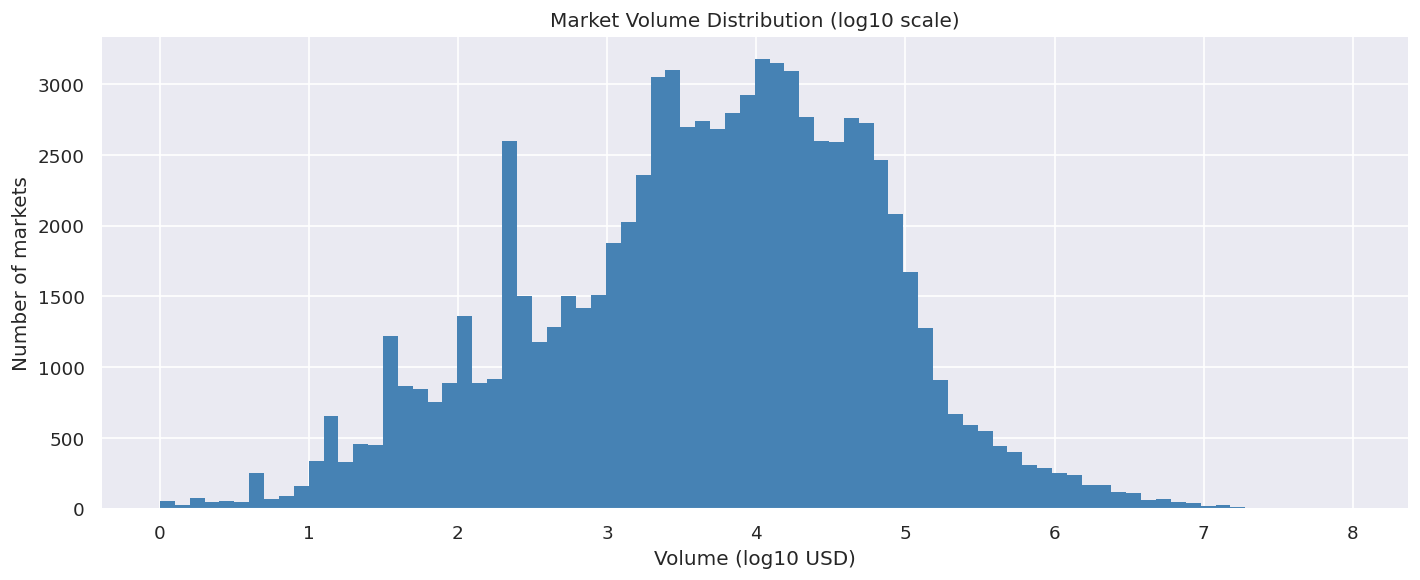

In [22]:
import numpy as np

# Log-transform volume for better visualization
vol_data = markets[markets['volume'] > 1]['volume']

fig, ax = plt.subplots()
ax.hist(np.log10(vol_data), bins=80, color='steelblue', edgecolor='none')
ax.set_xlabel('Volume (log10 USD)')
ax.set_ylabel('Number of markets')
ax.set_title('Market Volume Distribution (log10 scale)')
plt.tight_layout()
plt.show()

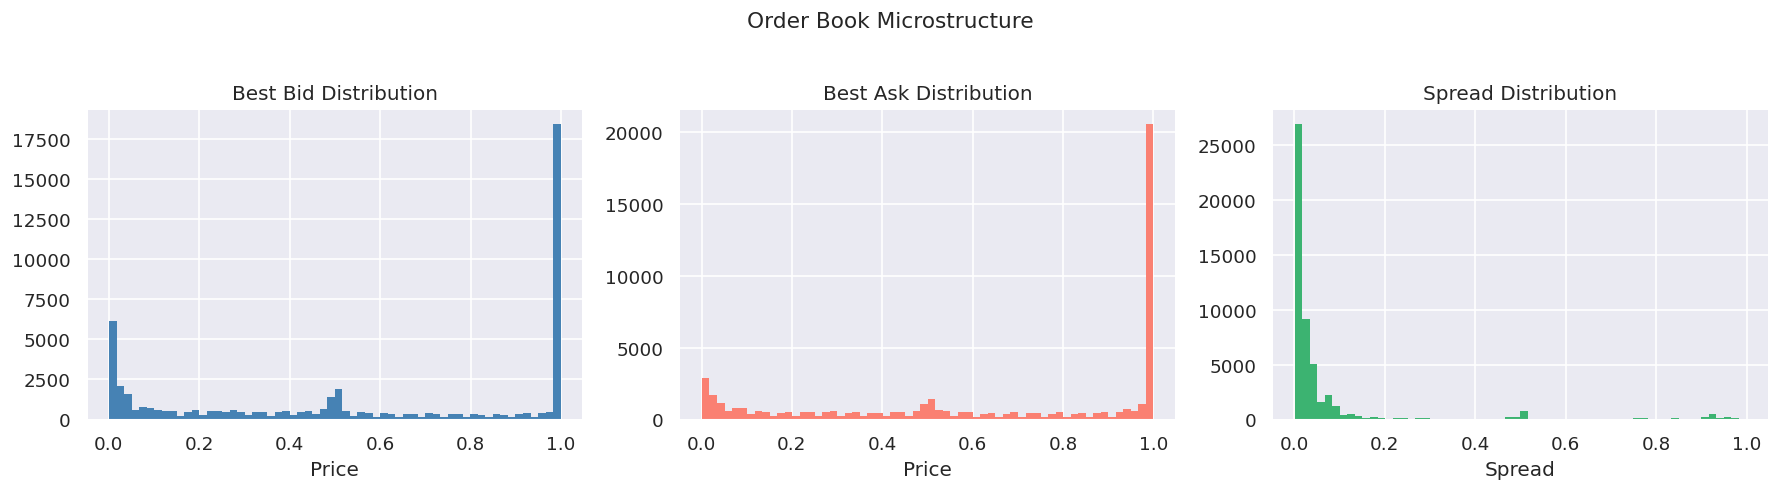

In [23]:
# Filter valid order book data
ob = markets[
    (markets['bestBid'] > 0) & 
    (markets['bestAsk'] > 0) & 
    (markets['bestAsk'] <= 1)
].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(ob['bestBid'], bins=60, color='steelblue', edgecolor='none')
axes[0].set_title('Best Bid Distribution')
axes[0].set_xlabel('Price')

axes[1].hist(ob['bestAsk'], bins=60, color='salmon', edgecolor='none')
axes[1].set_title('Best Ask Distribution')
axes[1].set_xlabel('Price')

axes[2].hist(ob['spread'], bins=60, color='mediumseagreen', edgecolor='none')
axes[2].set_title('Spread Distribution')
axes[2].set_xlabel('Spread')

plt.suptitle('Order Book Microstructure', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

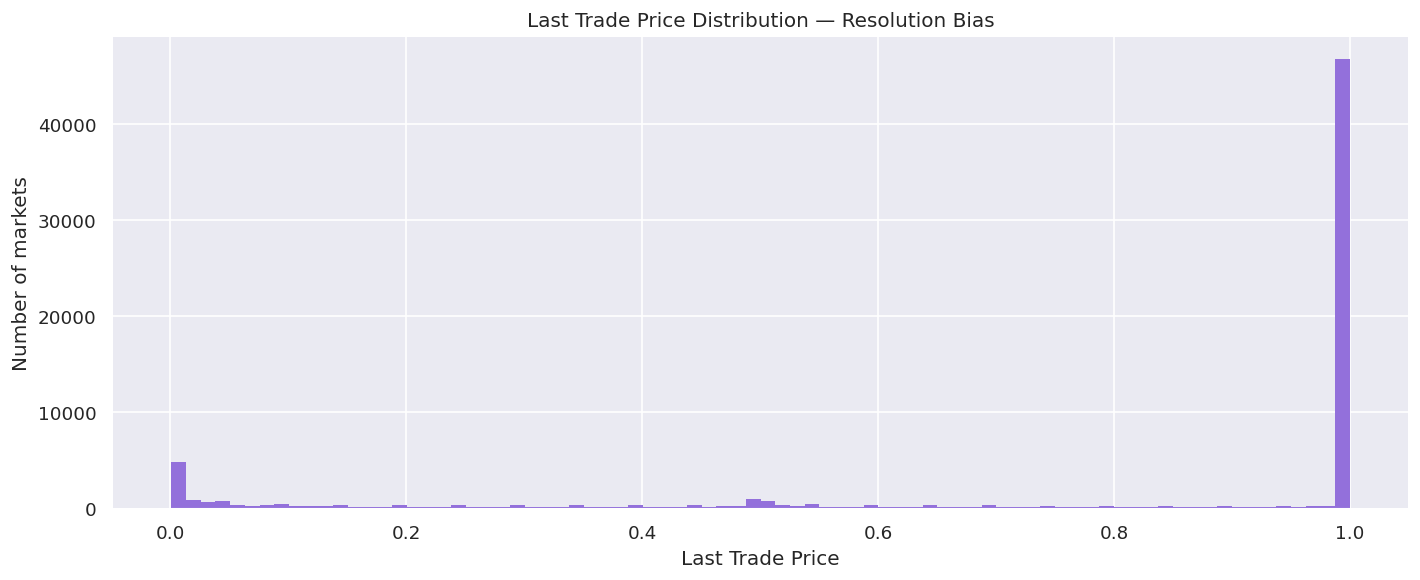

In [24]:
# lastTradePrice distribution - reveals market resolution bias
vol_data = markets[markets['lastTradePrice'] > 0]['lastTradePrice']

fig, ax = plt.subplots()
ax.hist(vol_data, bins=80, color='mediumpurple', edgecolor='none')
ax.set_xlabel('Last Trade Price')
ax.set_ylabel('Number of markets')
ax.set_title('Last Trade Price Distribution — Resolution Bias')
plt.tight_layout()
plt.show()

In [25]:
events['createdAt'] = pd.to_datetime(events['createdAt'], format='ISO8601')

In [26]:
# Event creation over time - growth trend
events['createdAt'] = pd.to_datetime(events['createdAt'])
events_by_month = events.groupby(events['createdAt'].dt.to_period('M')).size().reset_index()
events_by_month.columns = ['month', 'count']
events_by_month['month'] = events_by_month['month'].astype(str)

fig = px.line(
    events_by_month,
    x='month',
    y='count',
    title='Event Creation Over Time (Monthly)',
    markers=True
)
fig.update_xaxes(tickangle=45)
fig.show()

/tmp/ipykernel_27815/1481293370.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  events_by_month = events.groupby(events['createdAt'].dt.to_period('M')).size().reset_index()


In [27]:
# Liquidity vs Volume scatter - market quality quadrants
sample = markets[
    (markets['volume'] > 0) & 
    (markets['liquidity'] > 0)
].sample(5000, random_state=42)

fig = px.scatter(
    sample,
    x='volume',
    y='liquidity',
    log_x=True,
    log_y=True,
    opacity=0.4,
    title='Liquidity vs Volume (log scale, n=5000)',
    color_discrete_sequence=['steelblue']
)
fig.show()

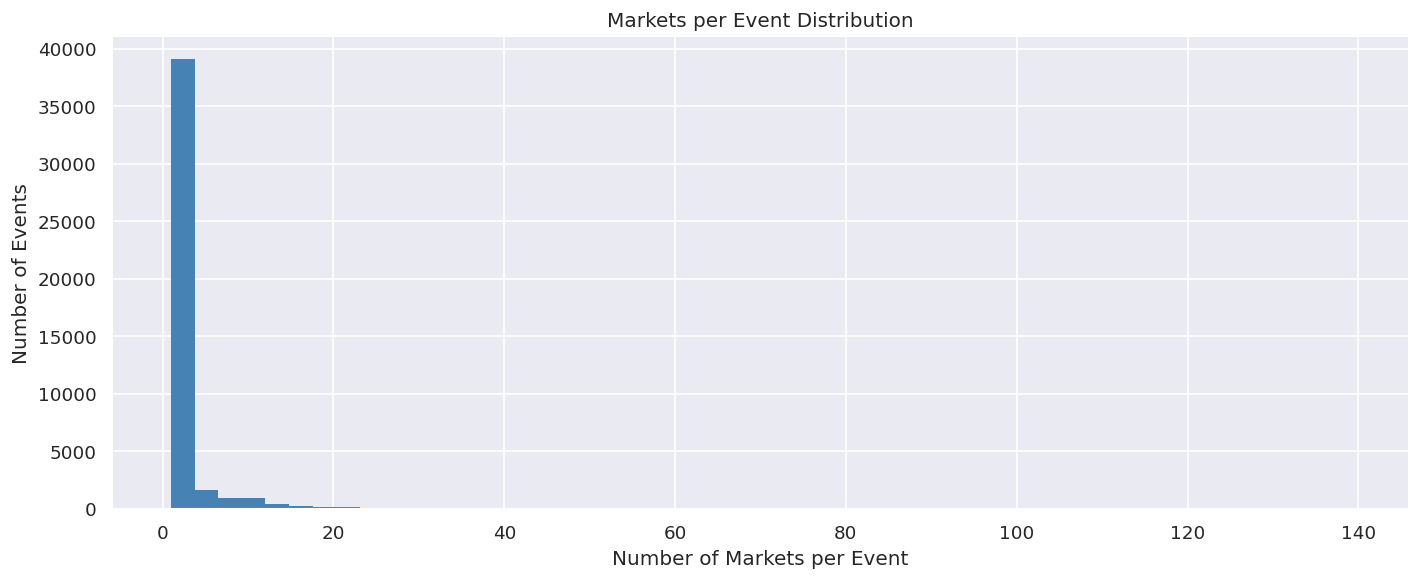

In [28]:
# Market count per event distribution
market_counts = markets.groupby('event_id').size().reset_index()
market_counts.columns = ['event_id', 'market_count']

fig, ax = plt.subplots()
ax.hist(market_counts['market_count'], bins=50, color='steelblue', edgecolor='none')
ax.set_xlabel('Number of Markets per Event')
ax.set_ylabel('Number of Events')
ax.set_title('Markets per Event Distribution')
plt.tight_layout()
plt.show()

In [29]:
# Top events by volume
top_events = events.nlargest(15, 'volume')[['title', 'volume', 'category']].reset_index(drop=True)

fig = px.bar(
    top_events,
    x='volume',
    y='title',
    orientation='h',
    color='category',
    title='Top 15 Events by Total Volume (USD)',
    text_auto='.2s'
)
fig.update_layout(yaxis={'categoryorder': 'total ascending'}, height=550)
fig.show()

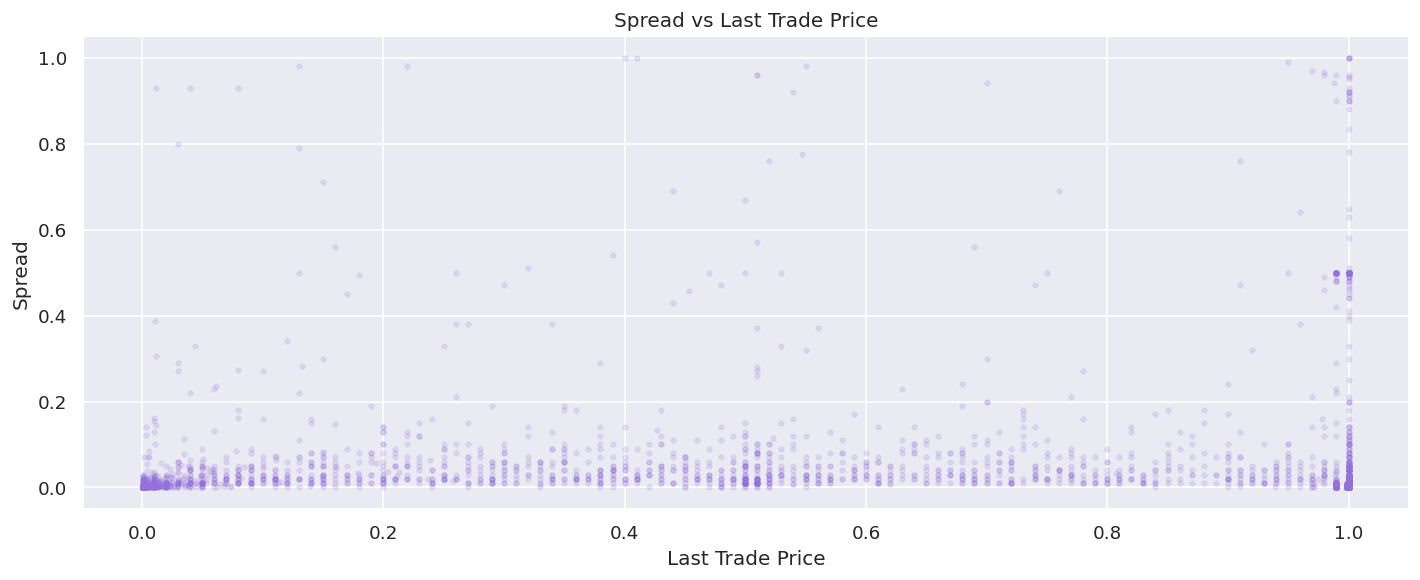

In [30]:
# Spread vs lastTradePrice - are extreme-priced markets less liquid?
sample = markets[
    (markets['spread'] > 0) &
    (markets['lastTradePrice'] > 0) &
    (markets['bestAsk'] <= 1)
].sample(5000, random_state=42)

fig, ax = plt.subplots()
ax.scatter(sample['lastTradePrice'], sample['spread'], alpha=0.15, s=8, color='mediumpurple')
ax.set_xlabel('Last Trade Price')
ax.set_ylabel('Spread')
ax.set_title('Spread vs Last Trade Price')
plt.tight_layout()
plt.show()

In [31]:
# Active vs closed vs archived breakdown
status = pd.DataFrame({
    'status': ['Active & Open', 'Active & Closed', 'Inactive', 'Archived'],
    'count': [
        len(markets[(markets['active'] == True) & (markets['closed'] == False)]),
        len(markets[(markets['active'] == True) & (markets['closed'] == True)]),
        len(markets[(markets['active'] == False) & (markets['closed'] == False)]),
        len(markets[markets['archived'] == True])
    ]
})

fig = px.pie(
    status,
    names='status',
    values='count',
    title='Market Status Breakdown',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

In [33]:
# Weekly volume trend across all markets
markets['endDate'] = pd.to_datetime(markets['endDate'], format='ISO8601')
weekly = markets[markets['volume1wk'] > 0].groupby(
    markets['endDate'].dt.to_period('W')
)['volume1wk'].sum().reset_index()
weekly.columns = ['week', 'volume']
weekly['week'] = weekly['week'].astype(str)

fig = px.line(
    weekly,
    x='week',
    y='volume',
    title='Weekly Volume Trend (by market end date)',
    markers=False
)
fig.update_xaxes(tickangle=45)
fig.show()

/tmp/ipykernel_27815/3932370735.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  markets['endDate'].dt.to_period('W')


In [34]:
# Volume concentration - what % of markets drive 80% of volume
markets_sorted = markets[markets['volume'] > 0].sort_values('volume', ascending=False)
total_volume = markets_sorted['volume'].sum()
cumsum = markets_sorted['volume'].cumsum()
pct_80 = (cumsum <= total_volume * 0.80).sum() / len(markets_sorted) * 100
pct_80, len(markets_sorted)

(np.float64(5.379226535134748), 83934)

In [35]:
# Win rate of active vs closed markets
markets[['active', 'closed']].value_counts(normalize=True).round(3)

active  closed
True    True      0.747
        False     0.163
False   False     0.079
        True      0.011
Name: proportion, dtype: float64

In [36]:
# Average spread by market status
markets.groupby('closed')['spread'].agg(['mean', 'median', 'std']).round(4)

,mean,median,std
closed,,,
False,0.4346,0.100,0.4546
True,0.1699,0.001,0.3492


In [37]:
# Correlation between key financial metrics
financial_cols = ['volume', 'liquidity', 'spread', 'bestBid', 'bestAsk', 'lastTradePrice', 'competitive']
markets[financial_cols].corr().round(3)

,volume,liquidity,spread,bestBid,bestAsk,lastTradePrice,competitive
volume,1.000,0.736,-0.042,-0.003,-0.047,-0.008,0.087
liquidity,0.736,1.000,-0.083,-0.010,-0.098,-0.031,0.184
spread,-0.042,-0.083,1.000,-0.653,0.545,-0.680,-0.409
bestBid,-0.003,-0.010,-0.653,1.000,0.386,0.910,-0.049
bestAsk,-0.047,-0.098,0.545,0.386,1.000,-0.157,-0.469
lastTradePrice,-0.008,-0.031,-0.680,0.910,-0.157,1.000,-0.074
competitive,0.087,0.184,-0.409,-0.049,-0.469,-0.074,1.000


In [38]:
# Zero volume markets - how many and what % are still active
zero_vol = markets[markets['volume'] == 0]
zero_vol[['active', 'closed']].value_counts()

active  closed
False   False     7842
True    True      1499
False   True      1059
Name: count, dtype: int64

In [ ]:
# =============================================================================
# EDA CONCLUSIONS
# =============================================================================

# VOLUME CONCENTRATION (Power Law)
# Only 5.4% of markets generate 80% of total trading volume.
# The distribution follows a power law — a small number of high-profile events
# (elections, Fed decisions, major crypto moves) dominate the entire platform.

# MARKET STATUS
# 74.7% of markets are active=True, closed=True (already resolved).
# Only 16.3% are live and open. The dataset is predominantly historical,
# making it suitable for supervised learning on resolved outcomes.

# SPREAD AS A LIQUIDITY PROXY
# Open markets (closed=False) show a mean spread of 0.43 vs 0.17 for closed ones.
# High spread = high uncertainty = low liquidity. As markets approach resolution,
# prices converge to 0 or 1 and spreads compress — consistent with efficient markets.

# KEY CORRELATIONS
# volume <-> liquidity: 0.736 — liquid markets attract volume (self-reinforcing)
# bestBid <-> lastTradePrice: 0.910 — bid price is nearly a proxy for last trade
# spread <-> lastTradePrice: -0.680 — extreme prices (near 0 or 1) have tight spreads;
#   uncertain markets (near 0.5) have wide spreads — market efficiency in action
# competitive <-> bestAsk: -0.469 — competitive markets have lower ask prices

# ZERO-VOLUME MARKETS
# ~10,400 markets never traded. 61% are inactive and unclosed —
# likely created speculatively but never attracted liquidity.
# These will be excluded from modeling and microstructure analysis.